# SpineNET — Architecture Exploration

Sandbox notebook: compare keypoint detection vs segmentation
architectures on MaIA Scoliosis Dataset.

- **Resolution:** 512 x 256 (H x W)
- **Compute:** device-agnostic via `ai.utils.get_device()`
- **Cobb validation:** post-hoc via `ai.evaluation.cobb`
- **Runs logged to:** in-memory `RUN_LOG` list

In [1]:
import json
import math
import os
import sys
import time
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import functional as TF

_nb_dir = Path.cwd()
for _p in [_nb_dir, *_nb_dir.parents]:
    if (_p / "ai").is_dir() and (_p / "params.yaml").is_file():
        REPO_ROOT = _p
        break
else:
    raise RuntimeError("Could not locate repo root")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"REPO_ROOT = {REPO_ROOT}")

REPO_ROOT = /home/ortiz/scoliosis


In [2]:
with open(REPO_ROOT / "params.yaml") as f:
    PARAMS = yaml.safe_load(f)

SEED: int = int(PARAMS["data"]["random_seed"])
TEST_SIZE: float = float(PARAMS["data"]["test_size"])
BATCH_SIZE: int = int(PARAMS["train"]["batch_size"])
LEARNING_RATE: float = float(PARAMS["train"]["learning_rate"])
EPOCHS: int = int(PARAMS["train"]["epochs"])

DATA_ROOT = REPO_ROOT / "data" / "raw" / "MaIA_Scoliosis_Dataset"
AUDIT_DIR = REPO_ROOT / "data" / "processed" / "audit"
CLEAN_INDEX_PATH = AUDIT_DIR / "clean_index.csv"
CHECKPOINT_DIR = REPO_ROOT / "data" / "processed" / "spinenet_ckpts"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

IMG_H, IMG_W = 512, 256
NUM_TARGETS = 17           # T1..L5
NUM_KPS = NUM_TARGETS * 4  # 68
NUM_SEG_CLASSES = 1 + NUM_TARGETS  # 18

print(f"SEED={SEED}  BS={BATCH_SIZE}  LR={LEARNING_RATE}  EPOCHS={EPOCHS}")

SEED=42  BS=4  LR=0.001  EPOCHS=50


In [3]:
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

from ai.utils import get_device, describe_device

DEVICE_INFO = get_device()
DEVICE = DEVICE_INFO.device
print(describe_device(DEVICE_INFO))

[device] backend=directml device=privateuseone:0 name=DirectML: AMD GPU


In [4]:
from ai.evaluation.cobb import cobb_from_keypoints, cobb_from_segmentation
from ai.preprocessing.keypoints import (
    KEYPOINTS_PER_VERTEBRA,
    TOTAL_KEYPOINTS,
    multiclass_mask_to_keypoints,
)
from ai.preprocessing.segmentation import remap_to_target_classes

In [5]:
def param_count(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def severity_bucket(deg: float) -> str:
    if deg < 10: return "normal"
    if deg < 25: return "mild"
    if deg < 40: return "moderate"
    return "severe"

## 1 · Data loading

In [6]:
assert CLEAN_INDEX_PATH.exists(), f"Run the audit notebook first: {CLEAN_INDEX_PATH}"
CLEAN_INDEX = pd.read_csv(CLEAN_INDEX_PATH)

# Keep ok + warn only
TRAINABLE = CLEAN_INDEX[CLEAN_INDEX["status"].isin(["ok", "warn"])].copy()

# Hard drops (known bad cases)
HARD_DROPS = {"S_0107"}
TRAINABLE = TRAINABLE[~TRAINABLE["image_path"].apply(
    lambda p: Path(p).stem in HARD_DROPS
)].reset_index(drop=True)

print(f"clean_index: {len(CLEAN_INDEX)}  trainable: {len(TRAINABLE)}")
for cat, n in TRAINABLE["category"].value_counts().items():
    print(f"  {cat:<10} {int(n):>4}")

clean_index: 250  trainable: 152
  Scoliosis    82
  Normal       70


In [7]:
def patient_stratified_split(
    df: pd.DataFrame,
    *,
    test_size: float = TEST_SIZE,
    seed: int = SEED,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Split by (patient_id, category), stratified by category."""
    rng = np.random.default_rng(seed)
    train_keys: list[tuple] = []
    val_keys: list[tuple] = []
    for category, group in df.groupby("category"):
        pids = sorted(group["patient_id"].unique(), key=str)
        perm = rng.permutation(len(pids))
        pids_shuf = [pids[i] for i in perm]
        n_val = max(1, int(round(len(pids_shuf) * test_size)))
        val_keys.extend((pid, category) for pid in pids_shuf[:n_val])
        train_keys.extend((pid, category) for pid in pids_shuf[n_val:])

    train_set, val_set = set(train_keys), set(val_keys)
    keys = list(zip(df["patient_id"], df["category"]))
    train_mask = np.array([k in train_set for k in keys])
    val_mask = np.array([k in val_set for k in keys])
    return df[train_mask].reset_index(drop=True), df[val_mask].reset_index(drop=True)


TRAIN_DF, VAL_DF = patient_stratified_split(TRAINABLE)
assert len(TRAIN_DF) + len(VAL_DF) == len(TRAINABLE)
print(f"train: {len(TRAIN_DF)}  val: {len(VAL_DF)}")

train: 122  val: 30


## 2 · Dataset + DataLoader

In [8]:
def hflip_keypoints(kps: np.ndarray, img_w: int) -> np.ndarray:
    out = kps.copy()
    out[:, 0] = (img_w - 1) - out[:, 0]
    k = out.reshape(-1, KEYPOINTS_PER_VERTEBRA, 2)
    k[:, [0, 1]] = k[:, [1, 0]]
    k[:, [2, 3]] = k[:, [3, 2]]
    return k.reshape(-1, 2)


def affine_keypoints(
    kps: torch.Tensor, valid: torch.Tensor,
    angle_deg: float, tx: float, ty: float, scale: float,
    w: int, h: int,
) -> torch.Tensor:
    cx, cy = w / 2.0, h / 2.0
    a = math.radians(angle_deg)
    cos_a, sin_a = math.cos(a), math.sin(a)
    out = kps.clone()
    dx, dy = out[:, 0] - cx, out[:, 1] - cy
    out[:, 0] = scale * (cos_a * dx + sin_a * dy) + cx + tx
    out[:, 1] = scale * (-sin_a * dx + cos_a * dy) + cy + ty
    out[~valid] = 0.0
    return out

In [9]:
class SpineDataset(Dataset):
    """Yields (image, targets, meta). Targets: keypoints, valid_kps, seg_mask."""

    def __init__(
        self, df: pd.DataFrame, *,
        img_h: int = IMG_H, img_w: int = IMG_W,
        augment: bool = False, seed: int | None = None,
    ) -> None:
        self.df = df.reset_index(drop=True)
        self.img_h, self.img_w = img_h, img_w
        self.augment = augment
        self._rng = np.random.default_rng(seed)

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]

        # Load + resize image
        img_pil = Image.open(row["image_path"]).convert("L")
        orig_w, orig_h = img_pil.size
        img_np = np.asarray(
            img_pil.resize((self.img_w, self.img_h), Image.BILINEAR),
            dtype=np.float32,
        ) / 255.0

        # Load + remap + resize seg mask
        mask_np = np.array(Image.open(row["multiclass_mask_path"]))
        if mask_np.ndim == 3:
            mask_np = mask_np[..., 0]
        mask_np = mask_np.astype(np.int32)
        remapped = remap_to_target_classes(mask_np)
        seg_np = np.array(
            Image.fromarray(remapped, mode="L").resize(
                (self.img_w, self.img_h), Image.NEAREST
            ),
            dtype=np.int64,
        )

        # Keypoints: extract + scale to training resolution
        kps = multiclass_mask_to_keypoints(mask_np).astype(np.float32).copy()
        kps[:, 0] *= self.img_w / orig_w
        kps[:, 1] *= self.img_h / orig_h

        # Horizontal flip
        if self.augment and self._rng.random() < 0.5:
            img_np = img_np[:, ::-1].copy()
            seg_np = seg_np[:, ::-1].copy()
            kps = hflip_keypoints(kps, self.img_w)

        # Pack tensors
        image_t = torch.from_numpy(img_np).unsqueeze(0)
        seg_t = torch.from_numpy(seg_np)
        valid = np.isfinite(kps).all(axis=1)
        kps_filled = np.where(valid[:, None], kps, 0.0).astype(np.float32)
        kps_t = torch.from_numpy(kps_filled)
        valid_t = torch.from_numpy(valid)

        # Affine augmentation (tensor space)
        if self.augment and self._rng.random() < 0.5:
            angle = float(self._rng.uniform(-5, 5))
            tx = float(self._rng.uniform(-0.05, 0.05)) * self.img_w
            ty = float(self._rng.uniform(-0.05, 0.05)) * self.img_h
            sc = float(self._rng.uniform(0.9, 1.1))
            image_t = TF.affine(
                image_t, angle=angle, translate=[tx, ty], scale=sc,
                shear=[0.0], interpolation=TF.InterpolationMode.BILINEAR,
            )
            seg_3d = TF.affine(
                seg_t.unsqueeze(0).float(), angle=angle, translate=[tx, ty],
                scale=sc, shear=[0.0], interpolation=TF.InterpolationMode.NEAREST,
            )
            seg_t = seg_3d.squeeze(0).long()
            kps_t = affine_keypoints(
                kps_t, valid_t, angle, tx, ty, sc, self.img_w, self.img_h,
            )

        # Intensity jitter
        if self.augment and self._rng.random() < 0.5:
            gain = float(self._rng.uniform(0.8, 1.2))
            bias = float(self._rng.uniform(-0.1, 0.1))
            image_t = (image_t * gain + bias).clamp(0, 1)

        targets = {"keypoints": kps_t, "valid_kps": valid_t, "seg_mask": seg_t}
        meta = {
            "patient_id": row.get("patient_id"),
            "category": row.get("category"),
            "orig_h": orig_h, "orig_w": orig_w,
            "cobb_deg": float(row.get("cobb_angle_deg", float("nan"))),
        }
        return image_t, targets, meta

In [10]:
def make_loaders(
    train_df: pd.DataFrame, val_df: pd.DataFrame, *,
    batch_size: int = BATCH_SIZE, seed: int = SEED,
) -> tuple[DataLoader, DataLoader]:
    train_ds = SpineDataset(train_df, augment=True, seed=seed)
    val_ds = SpineDataset(val_df, augment=False)
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0),
    )


# Smoke test
_ds = SpineDataset(TRAIN_DF.head(1), augment=False)
_img, _tgt, _meta = _ds[0]
print(f"image: {_img.shape}  seg: {_tgt['seg_mask'].shape}  kps: {_tgt['keypoints'].shape}")
del _ds, _img, _tgt, _meta

image: torch.Size([1, 512, 256])  seg: torch.Size([512, 256])  kps: torch.Size([68, 2])


## 3 · Model architectures

In [11]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch: int, out_ch: int) -> None:
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNetBackbone(nn.Module):
    """4-level U-Net encoder+decoder. Returns (feature_map, bottleneck)."""

    def __init__(self, in_ch: int = 1, init_ch: int = 64) -> None:
        super().__init__()
        c1, c2, c3, c4 = init_ch, init_ch * 2, init_ch * 4, init_ch * 8
        self.enc1 = DoubleConv(in_ch, c1)
        self.enc2 = DoubleConv(c1, c2)
        self.enc3 = DoubleConv(c2, c3)
        self.enc4 = DoubleConv(c3, c4)
        self.pool = nn.MaxPool2d(2)
        self.up3 = nn.ConvTranspose2d(c4, c3, 2, stride=2)
        self.dec3 = DoubleConv(c4, c3)
        self.up2 = nn.ConvTranspose2d(c3, c2, 2, stride=2)
        self.dec2 = DoubleConv(c3, c2)
        self.up1 = nn.ConvTranspose2d(c2, c1, 2, stride=2)
        self.dec1 = DoubleConv(c2, c1)
        self.out_channels = c1
        self.bottleneck_channels = c4

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(e4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return d1, e4

In [12]:
class KeypointRegressor(nn.Module):
    """Bottleneck -> global pool -> MLP -> (B, 68, 2)."""

    def __init__(self, init_ch: int = 64) -> None:
        super().__init__()
        self.backbone = UNetBackbone(in_ch=1, init_ch=init_ch)
        bot_c = self.backbone.bottleneck_channels
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(), nn.Linear(bot_c, 256), nn.ReLU(inplace=True),
            nn.Linear(256, TOTAL_KEYPOINTS * 2),
        )

    def forward(self, x):
        _, bot = self.backbone(x)
        return self.head(self.pool(bot)).view(-1, TOTAL_KEYPOINTS, 2)


class KeypointHeatmap(nn.Module):
    """Feature map -> 68 heatmap channels; argmax -> coords."""

    def __init__(self, init_ch: int = 64) -> None:
        super().__init__()
        self.backbone = UNetBackbone(in_ch=1, init_ch=init_ch)
        self.head = nn.Conv2d(self.backbone.out_channels, TOTAL_KEYPOINTS, 1)

    def forward(self, x):
        feat, _ = self.backbone(x)
        return self.head(feat)


class Segmenter(nn.Module):
    """Feature map -> 1x1 conv -> (B, C, H, W)."""

    def __init__(self, init_ch: int = 64) -> None:
        super().__init__()
        self.backbone = UNetBackbone(in_ch=1, init_ch=init_ch)
        self.head = nn.Conv2d(self.backbone.out_channels, NUM_SEG_CLASSES, 1)

    def forward(self, x):
        feat, _ = self.backbone(x)
        return self.head(feat)


class SegmenterDeep(nn.Module):
    """Segmenter + extra refine block + dropout."""

    def __init__(self, init_ch: int = 64) -> None:
        super().__init__()
        self.backbone = UNetBackbone(in_ch=1, init_ch=init_ch)
        c = self.backbone.out_channels
        self.refine = nn.Sequential(DoubleConv(c, c), nn.Dropout2d(0.1))
        self.head = nn.Conv2d(c, NUM_SEG_CLASSES, 1)

    def forward(self, x):
        feat, _ = self.backbone(x)
        return self.head(self.refine(feat))

In [13]:
for name, cls in [
    ("KeypointRegressor", KeypointRegressor),
    ("KeypointHeatmap", KeypointHeatmap),
    ("Segmenter", Segmenter),
    ("SegmenterDeep", SegmenterDeep),
]:
    m = cls(init_ch=64)
    print(f"  {name:22s}  {param_count(m)/1e6:.2f}M")
    del m

  KeypointRegressor       7.87M
  KeypointHeatmap         7.70M


  Segmenter               7.70M
  SegmenterDeep           7.77M


## 4 · Loss functions + heatmap utilities

In [14]:
# -- Keypoint losses --

def masked_smooth_l1(pred: torch.Tensor, target: torch.Tensor,
                     valid: torch.Tensor) -> torch.Tensor:
    """Smooth L1 over valid keypoints. pred/target: (B,K,2), valid: (B,K)."""
    mask = valid.unsqueeze(-1).expand_as(pred).float()
    diff = F.smooth_l1_loss(pred * mask, target * mask, reduction="sum")
    return diff / mask.sum().clamp_min(1.0)


# -- Heatmap utilities --

def gaussian_heatmap(kps: torch.Tensor, valid: torch.Tensor,
                     h: int, w: int, sigma: float = 4.0) -> torch.Tensor:
    """Render (B, K, H, W) Gaussian heatmaps centred at each keypoint."""
    B, K, _ = kps.shape
    ys = torch.arange(h, device=kps.device).view(1, 1, h, 1).float()
    xs = torch.arange(w, device=kps.device).view(1, 1, 1, w).float()
    cx = kps[..., 0].view(B, K, 1, 1)
    cy = kps[..., 1].view(B, K, 1, 1)
    hm = torch.exp(-((xs - cx)**2 + (ys - cy)**2) / (2 * sigma**2))
    return hm * valid.view(B, K, 1, 1).float()


def coords_from_heatmap(hm: torch.Tensor) -> torch.Tensor:
    """(B, K, H, W) -> (B, K, 2) via argmax."""
    B, K, H, W = hm.shape
    idx = hm.view(B, K, -1).argmax(dim=-1)
    return torch.stack([(idx % W).float(), (idx // W).float()], dim=-1)


def masked_heatmap_mse(pred: torch.Tensor, target: torch.Tensor,
                       valid: torch.Tensor) -> torch.Tensor:
    """MSE over valid heatmap channels only."""
    per_ch = ((pred - target)**2).sum(dim=(-2, -1))
    valid_f = valid.float()
    return (per_ch * valid_f).sum() / valid_f.sum().clamp_min(1.0)


# -- Segmentation losses --

def soft_dice_loss(logits: torch.Tensor, target: torch.Tensor,
                   num_classes: int = NUM_SEG_CLASSES,
                   eps: float = 1e-6) -> torch.Tensor:
    """1 - mean Dice over foreground classes (skip bg=0)."""
    probs = F.softmax(logits, dim=1)
    onehot = torch.zeros_like(probs)
    onehot.scatter_(1, target.unsqueeze(1), 1.0)
    probs, onehot = probs[:, 1:], onehot[:, 1:]
    dims = (0, 2, 3)
    inter = (probs * onehot).sum(dim=dims)
    card = probs.sum(dim=dims) + onehot.sum(dim=dims)
    return 1.0 - ((2.0 * inter + eps) / (card + eps)).mean()


SEG_CLASS_WEIGHTS = torch.tensor(
    [0.1] + [1.0] * NUM_TARGETS, device=DEVICE,
)


def seg_combo_loss(logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    """0.3 * weighted CE + 0.7 * soft Dice."""
    ce = F.cross_entropy(logits, target, weight=SEG_CLASS_WEIGHTS)
    dice = soft_dice_loss(logits, target)
    return 0.3 * ce + 0.7 * dice

Dropped Escape call with ulEscapeCode : 0x03007703


## 5 · Metrics + evaluation helpers

In [15]:
def pck(pred: torch.Tensor, target: torch.Tensor,
        valid: torch.Tensor, img_h: int = IMG_H,
        img_w: int = IMG_W, thresh: float = 0.05) -> float:
    """Fraction of valid keypoints within `thresh` of image diagonal."""
    diag = (img_h**2 + img_w**2)**0.5
    dist = torch.linalg.norm(pred - target, dim=-1)
    hit = ((dist <= thresh * diag) & valid).float().sum()
    return float(hit / valid.float().sum().clamp_min(1.0))


def mean_dice(pred_idx: torch.Tensor, target_idx: torch.Tensor) -> float:
    """Mean Dice over classes 1..NUM_TARGETS (skip bg)."""
    dices: list[float] = []
    for cls in range(1, NUM_TARGETS + 1):
        p, t = (pred_idx == cls), (target_idx == cls)
        denom = p.float().sum().item() + t.float().sum().item()
        if denom == 0:
            continue
        dices.append(2.0 * (p & t).float().sum().item() / denom)
    return float(np.mean(dices)) if dices else 0.0

In [16]:
def case_id(meta: dict) -> str:
    """Build display ID like 'S_42' from meta dict."""
    cat = meta.get("category", "?")
    if not isinstance(cat, str):
        cat = str(cat)
    return f"{cat[0]}_{meta.get('patient_id', '?')}"


## 6 · Training engine

One generic `train()` function. Task-specific behavior injected via:
- `loss_fn(model, batch) -> loss` — computes the loss
- `eval_fn(model, batch) -> dict` — computes per-batch eval metrics

In [ ]:
@dataclass
class TrainResult:
    name: str
    task: str
    architecture: str
    history: list[dict] = field(default_factory=list)
    best_metrics: dict = field(default_factory=dict)
    hparams: dict = field(default_factory=dict)
    wall_clock_s: float = 0.0
    checkpoint_path: Path | None = None


RUN_LOG: list[TrainResult] = []


def train(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    *,
    loss_fn,
    eval_fn,
    name: str,
    task: str,
    architecture: str,
    hparams: dict,
    epochs: int = EPOCHS,
    lr: float = LEARNING_RATE,
    cosine: bool = False,
) -> TrainResult:
    """Generic training loop. Returns TrainResult appended to RUN_LOG."""
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    if cosine:
        sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optim, T_0=10, T_mult=2, eta_min=1e-6,
        )
    else:
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optim, mode="min", factor=0.5, patience=5,
        )
    best_primary = -1.0
    best_state: dict | None = None
    best_metrics: dict = {}
    history: list[dict] = []

    t_total = time.time()
    for epoch in range(1, epochs + 1):
        t0 = time.time()

        # Train
        model.train()
        tloss, n = 0.0, 0
        for batch in train_loader:
            loss = loss_fn(model, batch)
            optim.zero_grad(set_to_none=True)
            loss.backward()
            optim.step()
            tloss += float(loss); n += 1
        tloss /= max(n, 1)

        # Val
        model.eval()
        vloss, vn = 0.0, 0
        epoch_metrics: dict[str, list[float]] = {}
        with torch.no_grad():
            for batch in val_loader:
                vloss += float(loss_fn(model, batch)); vn += 1
                for k, v in eval_fn(model, batch).items():
                    epoch_metrics.setdefault(k, []).append(v)
        vloss /= max(vn, 1)

        if cosine:
            sched.step(epoch)
        else:
            sched.step(vloss)

        avg_metrics = {k: float(np.nanmean(vs)) for k, vs in epoch_metrics.items()}
        cur_lr = float(optim.param_groups[0]["lr"])
        row = {"epoch": epoch, "train_loss": tloss, "val_loss": vloss,
               "lr": cur_lr, "sec": time.time() - t0, **avg_metrics}
        history.append(row)

        # Track best by first metric in eval_fn output
        primary_key = next(iter(epoch_metrics))
        primary_val = avg_metrics[primary_key]
        if primary_val > best_primary:
            best_primary = primary_val
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_metrics = {**avg_metrics, "val_loss": vloss}

        # Print
        met_str = "  ".join(f"{k}={v:.3f}" for k, v in avg_metrics.items())
        print(f"  ep{epoch:02d}/{epochs}  tr={tloss:.4f}  va={vloss:.4f}  "
              f"{met_str}  lr={cur_lr:.1e}  ({time.time() - t0:.1f}s)")

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"  restored best ({primary_key}={best_primary:.3f})")

    wall = time.time() - t_total
    result = TrainResult(
        name=name, task=task, architecture=architecture,
        history=history, best_metrics=best_metrics,
        hparams=hparams, wall_clock_s=wall,
    )
    RUN_LOG.append(result)
    return result

In [18]:
# -- Keypoint regression --

def kp_regress_loss(model: nn.Module, batch) -> torch.Tensor:
    imgs, tgts, _ = batch
    pred = model(imgs.to(DEVICE))
    return masked_smooth_l1(pred, tgts["keypoints"].to(DEVICE),
                            tgts["valid_kps"].to(DEVICE))


def kp_regress_eval(model: nn.Module, batch) -> dict[str, float]:
    imgs, tgts, metas = batch
    pred = model(imgs.to(DEVICE))
    kps_gt = tgts["keypoints"].to(DEVICE)
    valid = tgts["valid_kps"].to(DEVICE)
    pck_val = pck(pred, kps_gt, valid)

    pred_np = pred.detach().cpu().numpy()
    cobb_errs: list[float] = []
    sev_hits: list[float] = []
    for i in range(imgs.shape[0]):
        gt = float(metas["cobb_deg"][i])
        if math.isnan(gt):
            continue
        oh, ow = int(metas["orig_h"][i]), int(metas["orig_w"][i])
        kps_orig = pred_np[i].copy()
        kps_orig[:, 0] *= ow / IMG_W
        kps_orig[:, 1] *= oh / IMG_H
        pc = float(cobb_from_keypoints(kps_orig))
        cobb_errs.append(abs(pc - gt))
        sev_hits.append(float(severity_bucket(pc) == severity_bucket(gt)))

    cobb_mae = float(np.mean(cobb_errs)) if cobb_errs else float("nan")
    sev_acc = float(np.mean(sev_hits)) if sev_hits else float("nan")
    return {"pck": pck_val, "cobb_mae": cobb_mae, "sev_acc": sev_acc}


# -- Keypoint heatmap --

def kp_heatmap_loss(model: nn.Module, batch) -> torch.Tensor:
    imgs, tgts, _ = batch
    kps = tgts["keypoints"].to(DEVICE)
    valid = tgts["valid_kps"].to(DEVICE)
    target_hm = gaussian_heatmap(kps, valid, IMG_H, IMG_W)
    pred_hm = model(imgs.to(DEVICE))
    return masked_heatmap_mse(pred_hm, target_hm, valid)


def kp_heatmap_eval(model: nn.Module, batch) -> dict[str, float]:
    imgs, tgts, metas = batch
    kps_gt = tgts["keypoints"].to(DEVICE)
    valid = tgts["valid_kps"].to(DEVICE)
    pred_hm = model(imgs.to(DEVICE))
    pred_coords = coords_from_heatmap(pred_hm)
    pck_val = pck(pred_coords, kps_gt, valid)

    pred_np = pred_coords.detach().cpu().numpy()
    cobb_errs: list[float] = []
    sev_hits: list[float] = []
    for i in range(imgs.shape[0]):
        gt = float(metas["cobb_deg"][i])
        if math.isnan(gt):
            continue
        oh, ow = int(metas["orig_h"][i]), int(metas["orig_w"][i])
        kps_orig = pred_np[i].copy()
        kps_orig[:, 0] *= ow / IMG_W
        kps_orig[:, 1] *= oh / IMG_H
        pc = float(cobb_from_keypoints(kps_orig))
        cobb_errs.append(abs(pc - gt))
        sev_hits.append(float(severity_bucket(pc) == severity_bucket(gt)))

    cobb_mae = float(np.mean(cobb_errs)) if cobb_errs else float("nan")
    sev_acc = float(np.mean(sev_hits)) if sev_hits else float("nan")
    return {"pck": pck_val, "cobb_mae": cobb_mae, "sev_acc": sev_acc}


# -- Segmentation --

def seg_loss(model: nn.Module, batch) -> torch.Tensor:
    imgs, tgts, _ = batch
    logits = model(imgs.to(DEVICE))
    return seg_combo_loss(logits, tgts["seg_mask"].to(DEVICE).long())


def seg_eval(model: nn.Module, batch) -> dict[str, float]:
    imgs, tgts, metas = batch
    logits = model(imgs.to(DEVICE))
    pred_idx = logits.argmax(dim=1)
    seg_gt = tgts["seg_mask"].to(DEVICE).long()
    dice_val = mean_dice(pred_idx, seg_gt)

    pred_np = pred_idx.detach().cpu().numpy()
    cobb_errs: list[float] = []
    sev_hits: list[float] = []
    for i in range(imgs.shape[0]):
        gt = float(metas["cobb_deg"][i])
        if math.isnan(gt):
            continue
        pc = float(cobb_from_segmentation(pred_np[i]))
        cobb_errs.append(abs(pc - gt))
        sev_hits.append(float(severity_bucket(pc) == severity_bucket(gt)))

    cobb_mae = float(np.mean(cobb_errs)) if cobb_errs else float("nan")
    sev_acc = float(np.mean(sev_hits)) if sev_hits else float("nan")
    return {"dice": dice_val, "cobb_mae": cobb_mae, "sev_acc": sev_acc}


## 7 · Plotting helpers

In [19]:
def plot_history(result: TrainResult) -> None:
    """Loss curves + primary metric from a TrainResult."""
    df = pd.DataFrame(result.history)
    metric_cols = [c for c in df.columns
                   if c not in {"epoch", "train_loss", "val_loss", "lr", "sec"}]
    primary = metric_cols[0] if metric_cols else None

    ncols = 2 if primary else 1
    fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 3.5))
    if ncols == 1:
        axes = [axes]

    axes[0].plot(df["epoch"], df["train_loss"], label="train")
    axes[0].plot(df["epoch"], df["val_loss"], "--", label="val")
    axes[0].set(xlabel="epoch", ylabel="loss", title=f"{result.name} — loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    if primary:
        axes[1].plot(df["epoch"], df[primary], color="green")
        axes[1].set(xlabel="epoch", ylabel=primary,
                    title=f"{result.name} — {primary}")
        axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_seg_predictions(model: nn.Module, val_df: pd.DataFrame,
                         n: int = 4) -> None:
    """3-panel grid: radiograph | GT seg | predicted seg."""
    ds = SpineDataset(val_df.head(n), augment=False)
    fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
    if n == 1:
        axes = axes[None, :]

    model.eval()
    for i in range(min(n, len(ds))):
        img_t, tgts, meta = ds[i]
        seg_gt = tgts["seg_mask"].numpy()
        with torch.no_grad():
            logits = model(img_t.unsqueeze(0).to(DEVICE))
        seg_pred = logits.argmax(dim=1).squeeze(0).cpu().numpy()

        cid = case_id(meta)
        axes[i, 0].imshow(img_t.squeeze(0), cmap="gray")
        axes[i, 0].set_title(f"{cid}"); axes[i, 0].set_axis_off()
        axes[i, 1].imshow(seg_gt, cmap="tab20", vmin=0, vmax=NUM_SEG_CLASSES - 1)
        axes[i, 1].set_title("ground truth"); axes[i, 1].set_axis_off()
        axes[i, 2].imshow(seg_pred, cmap="tab20", vmin=0, vmax=NUM_SEG_CLASSES - 1)
        axes[i, 2].set_title("predicted"); axes[i, 2].set_axis_off()

    plt.tight_layout()
    plt.show()


def plot_kp_predictions(model: nn.Module, val_df: pd.DataFrame,
                        n: int = 4, is_heatmap: bool = False) -> None:
    """Overlay predicted keypoints (red) and GT (green) on radiographs."""
    ds = SpineDataset(val_df.head(n), augment=False)
    fig, axes = plt.subplots(n, 1, figsize=(6, 4 * n))
    if n == 1:
        axes = [axes]

    model.eval()
    for i in range(min(n, len(ds))):
        img_t, tgts, meta = ds[i]
        kps_gt = tgts["keypoints"].numpy()
        valid = tgts["valid_kps"].numpy()

        with torch.no_grad():
            inp = img_t.unsqueeze(0).to(DEVICE)
            if is_heatmap:
                pred_hm = model(inp)
                pred_kps = coords_from_heatmap(pred_hm).squeeze(0).cpu().numpy()
            else:
                pred_kps = model(inp).squeeze(0).cpu().numpy()

        ax = axes[i]
        ax.imshow(img_t.squeeze(0), cmap="gray")
        ax.scatter(kps_gt[valid, 0], kps_gt[valid, 1], s=8, c="lime",
                   label="GT", zorder=3)
        ax.scatter(pred_kps[valid, 0], pred_kps[valid, 1], s=8, c="red",
                   marker="x", label="pred", zorder=3)
        ax.set_title(case_id(meta))
        ax.set_axis_off()
        if i == 0:
            ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

## 8 · Keypoint experiments

/home/ortiz/scoliosis/env/lib/python3.12/site-packages/torch/optim/adam.py:534: UserWarning: The operator 'aten::lerp.Scalar_out' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /__w/1/s/pytorch-directml-plugin/torch_directml/csrc/dml/dml_cpu_fallback.cpp:15.)
  torch._foreach_lerp_(device_exp_avgs, device_grads, 1 - beta1)


  ep01/5  tr=163.3178  va=126.9412  pck=0.000  cobb_mae=29.892  sev_acc=0.750  lr=1.0e-03  (16.2s)
  ep02/5  tr=91.6447  va=51.3562  pck=0.180  cobb_mae=15.671  sev_acc=0.700  lr=1.0e-03  (13.1s)
  ep03/5  tr=39.1497  va=29.4302  pck=0.286  cobb_mae=37.797  sev_acc=0.050  lr=1.0e-03  (14.5s)
  ep04/5  tr=26.3281  va=26.8854  pck=0.360  cobb_mae=39.387  sev_acc=0.050  lr=1.0e-03  (12.7s)
  ep05/5  tr=24.7244  va=24.4908  pck=0.387  cobb_mae=43.793  sev_acc=0.000  lr=1.0e-03  (13.0s)
  restored best (pck=0.387)


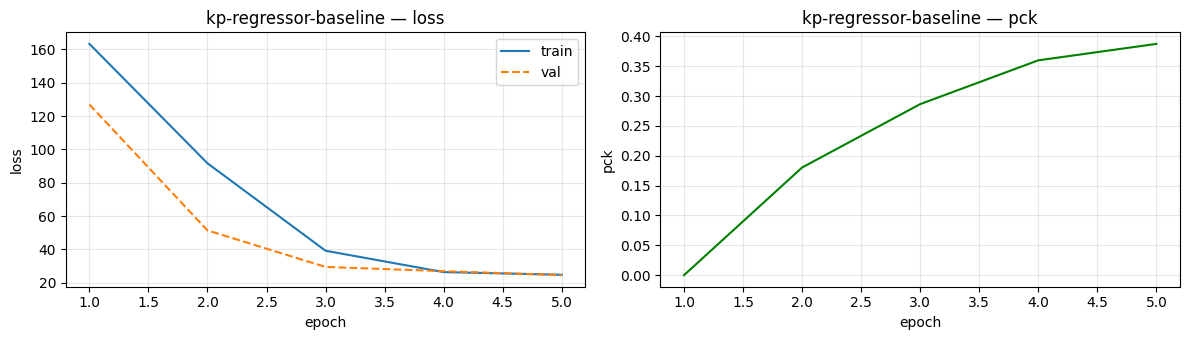

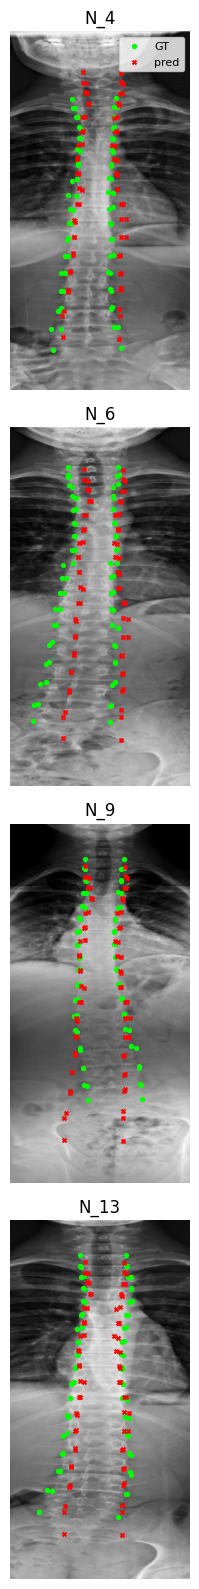

In [20]:
train_loader, val_loader = make_loaders(TRAIN_DF, VAL_DF)

kp_model = KeypointRegressor(init_ch=64).to(DEVICE)
kp_baseline = train(
    kp_model, train_loader, val_loader,
    loss_fn=kp_regress_loss, eval_fn=kp_regress_eval,
    name="kp-regressor-baseline", task="keypoint",
    architecture="regressor", hparams={"init_ch": 64},
    epochs=5, lr=LEARNING_RATE,
)
plot_history(kp_baseline)
plot_kp_predictions(kp_model, VAL_DF, n=4)

  ep01/5  tr=2139.2295  va=139.7937  pck=0.006  cobb_mae=30.506  sev_acc=0.750  lr=1.0e-03  (18.2s)
  ep02/5  tr=100.7252  va=64.2159  pck=0.008  cobb_mae=29.553  sev_acc=0.750  lr=1.0e-03  (15.6s)
  ep03/5  tr=71.3739  va=58.9390  pck=0.008  cobb_mae=29.807  sev_acc=0.750  lr=1.0e-03  (17.2s)
  ep04/5  tr=67.0755  va=57.1443  pck=0.008  cobb_mae=28.930  sev_acc=0.750  lr=1.0e-03  (15.4s)
  ep05/5  tr=64.3789  va=93.5720  pck=0.012  cobb_mae=28.300  sev_acc=0.750  lr=1.0e-03  (17.0s)
  restored best (pck=0.012)


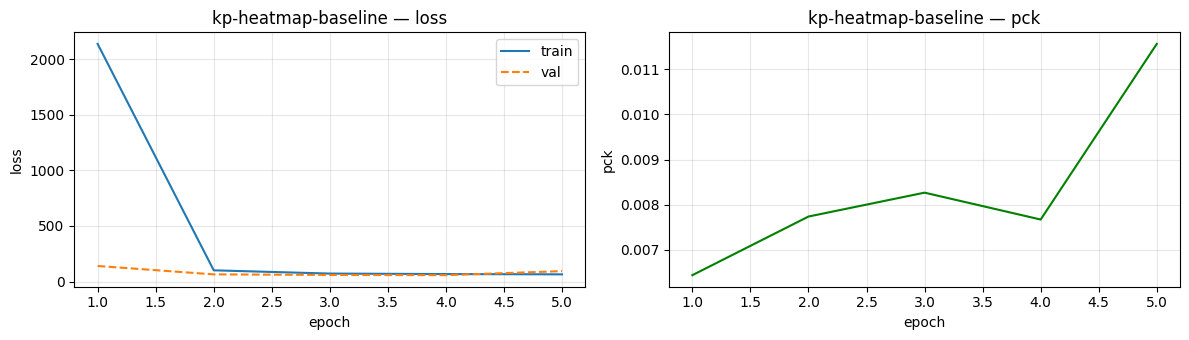

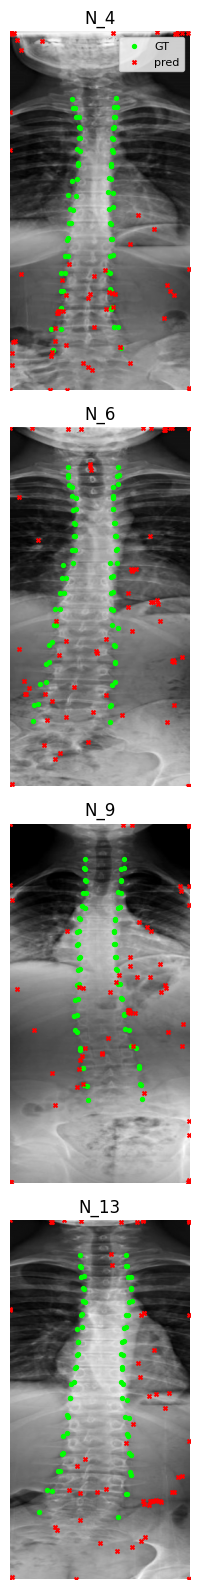

In [21]:
kp_hm_model = KeypointHeatmap(init_ch=64).to(DEVICE)
kp_heatmap = train(
    kp_hm_model, train_loader, val_loader,
    loss_fn=kp_heatmap_loss, eval_fn=kp_heatmap_eval,
    name="kp-heatmap-baseline", task="keypoint",
    architecture="heatmap", hparams={"init_ch": 64},
    epochs=5, lr=LEARNING_RATE,
)
plot_history(kp_heatmap)
plot_kp_predictions(kp_hm_model, VAL_DF, n=4, is_heatmap=True)

  ep01/50  tr=162.3127  va=135.4978  pck=0.000  cobb_mae=29.892  sev_acc=0.750  lr=1.0e-03  (12.6s)
  ep02/50  tr=88.6042  va=73.0478  pck=0.012  cobb_mae=29.735  sev_acc=0.250  lr=1.0e-03  (14.5s)
  ep03/50  tr=38.3318  va=27.0686  pck=0.351  cobb_mae=43.395  sev_acc=0.000  lr=1.0e-03  (12.5s)
  ep04/50  tr=26.2176  va=24.4212  pck=0.391  cobb_mae=48.674  sev_acc=0.000  lr=1.0e-03  (12.7s)
  ep05/50  tr=25.2353  va=24.5630  pck=0.351  cobb_mae=47.759  sev_acc=0.000  lr=1.0e-03  (14.4s)
  ep06/50  tr=24.9088  va=25.1167  pck=0.351  cobb_mae=47.551  sev_acc=0.000  lr=1.0e-03  (12.4s)
  ep07/50  tr=25.2042  va=23.3069  pck=0.393  cobb_mae=47.653  sev_acc=0.000  lr=1.0e-03  (14.4s)
  ep08/50  tr=24.8383  va=30.2126  pck=0.228  cobb_mae=43.331  sev_acc=0.000  lr=1.0e-03  (12.6s)
  ep09/50  tr=24.5841  va=28.0005  pck=0.349  cobb_mae=50.892  sev_acc=0.000  lr=1.0e-03  (12.4s)
  ep10/50  tr=24.2998  va=27.1489  pck=0.252  cobb_mae=50.879  sev_acc=0.000  lr=1.0e-03  (14.3s)
  ep11/50  tr=24.4

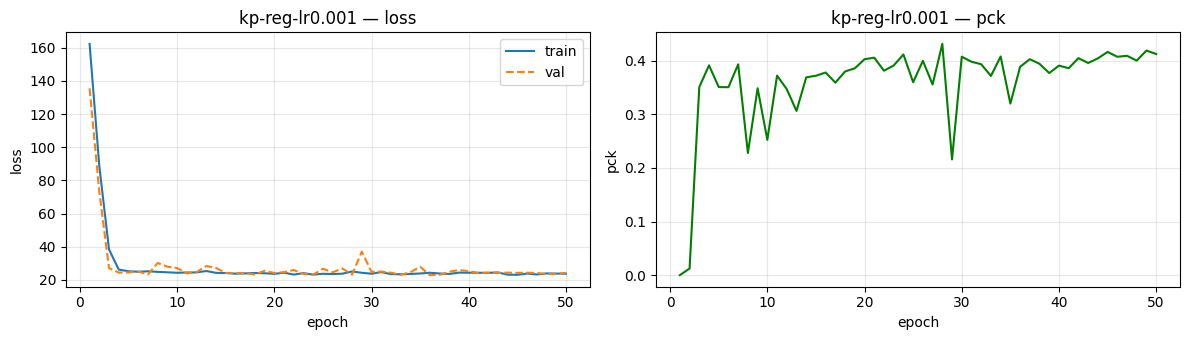

  ep01/50  tr=171.8579  va=158.6491  pck=0.000  cobb_mae=29.892  sev_acc=0.750  lr=5.0e-04  (12.8s)
  ep02/50  tr=148.6042  va=126.4680  pck=0.000  cobb_mae=29.892  sev_acc=0.750  lr=5.0e-04  (15.2s)
  ep03/50  tr=93.2956  va=58.0988  pck=0.144  cobb_mae=29.892  sev_acc=0.750  lr=5.0e-04  (13.2s)
  ep04/50  tr=53.3623  va=42.4546  pck=0.243  cobb_mae=28.917  sev_acc=0.300  lr=5.0e-04  (13.0s)
  ep05/50  tr=35.6608  va=29.8736  pck=0.353  cobb_mae=54.911  sev_acc=0.000  lr=5.0e-04  (14.3s)
  ep06/50  tr=27.9281  va=30.9365  pck=0.302  cobb_mae=46.202  sev_acc=0.000  lr=5.0e-04  (12.7s)
  ep07/50  tr=25.4764  va=27.7304  pck=0.387  cobb_mae=46.603  sev_acc=0.000  lr=5.0e-04  (14.1s)
  ep08/50  tr=24.5889  va=29.7573  pck=0.246  cobb_mae=50.912  sev_acc=0.000  lr=5.0e-04  (12.6s)
  ep09/50  tr=25.1488  va=28.9991  pck=0.302  cobb_mae=51.627  sev_acc=0.000  lr=5.0e-04  (12.7s)
  ep10/50  tr=25.9260  va=30.2066  pck=0.234  cobb_mae=55.022  sev_acc=0.000  lr=5.0e-04  (14.2s)
  ep11/50  tr=24

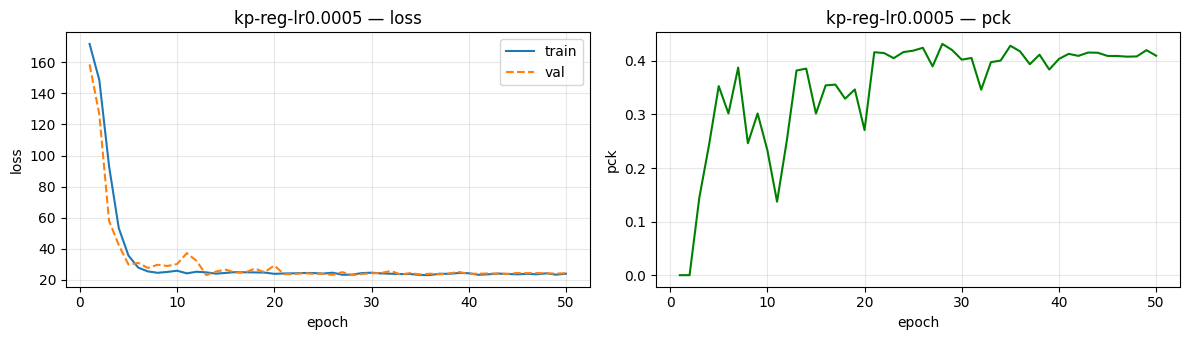

  ep01/50  tr=173.9217  va=166.9824  pck=0.000  cobb_mae=29.892  sev_acc=0.750  lr=1.0e-04  (12.8s)
  ep02/50  tr=172.9392  va=165.8639  pck=0.000  cobb_mae=29.892  sev_acc=0.750  lr=1.0e-04  (14.6s)
  ep03/50  tr=168.5489  va=162.3521  pck=0.000  cobb_mae=29.892  sev_acc=0.750  lr=1.0e-04  (13.0s)
  ep04/50  tr=165.0742  va=157.5354  pck=0.000  cobb_mae=29.892  sev_acc=0.750  lr=1.0e-04  (12.7s)
  ep05/50  tr=159.1676  va=149.2871  pck=0.000  cobb_mae=29.892  sev_acc=0.750  lr=1.0e-04  (14.6s)
  ep06/50  tr=150.2511  va=140.2400  pck=0.000  cobb_mae=29.892  sev_acc=0.750  lr=1.0e-04  (12.7s)
  ep07/50  tr=137.9321  va=125.9831  pck=0.000  cobb_mae=29.892  sev_acc=0.750  lr=1.0e-04  (14.4s)
  ep08/50  tr=126.4367  va=115.0614  pck=0.003  cobb_mae=29.892  sev_acc=0.750  lr=1.0e-04  (13.0s)
  ep09/50  tr=112.8789  va=99.5974  pck=0.015  cobb_mae=29.892  sev_acc=0.750  lr=1.0e-04  (12.5s)
  ep10/50  tr=97.0769  va=74.9052  pck=0.084  cobb_mae=29.892  sev_acc=0.750  lr=1.0e-04  (14.9s)
  e

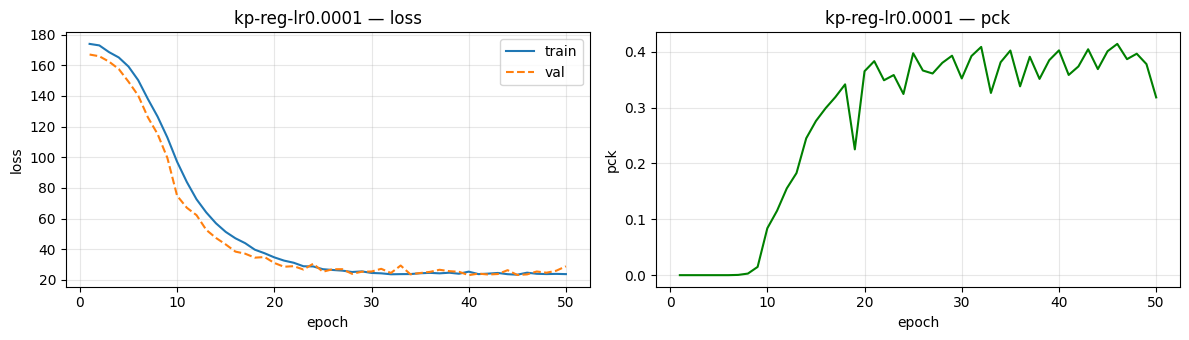

In [22]:
KP_SWEEP = [
    {"lr": 1e-3, "epochs": 50},
    {"lr": 5e-4, "epochs": 50},
    {"lr": 1e-4, "epochs": 50},
]

for cfg in KP_SWEEP:
    m = KeypointRegressor(init_ch=64).to(DEVICE)
    r = train(
        m, train_loader, val_loader,
        loss_fn=kp_regress_loss, eval_fn=kp_regress_eval,
        name=f"kp-reg-lr{cfg['lr']}", task="keypoint",
        architecture="regressor", hparams={"init_ch": 64, **cfg},
        epochs=cfg["epochs"], lr=cfg["lr"],
    )
    plot_history(r)

## 9 · Segmentation experiments

  ep01/5  tr=1.4404  va=1.4119  dice=0.003  cobb_mae=55.789  sev_acc=0.200  lr=1.0e-03  (18.7s)
  ep02/5  tr=1.3529  va=1.3258  dice=0.000  cobb_mae=60.108  sev_acc=0.000  lr=1.0e-03  (16.2s)
  ep03/5  tr=1.3197  va=1.3361  dice=0.000  cobb_mae=60.108  sev_acc=0.000  lr=1.0e-03  (17.8s)
  ep04/5  tr=1.3044  va=1.3347  dice=0.000  cobb_mae=60.108  sev_acc=0.000  lr=1.0e-03  (16.1s)
  ep05/5  tr=1.2779  va=1.2856  dice=0.017  cobb_mae=31.028  sev_acc=0.750  lr=1.0e-03  (18.0s)
  restored best (dice=0.017)


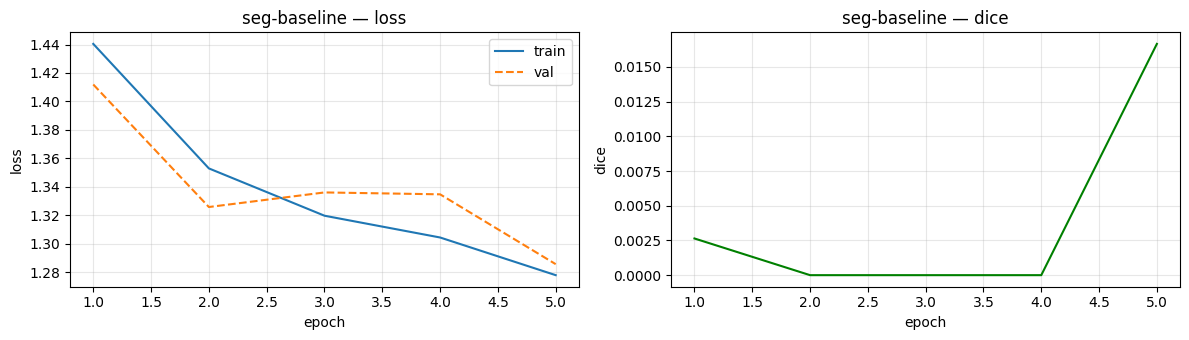

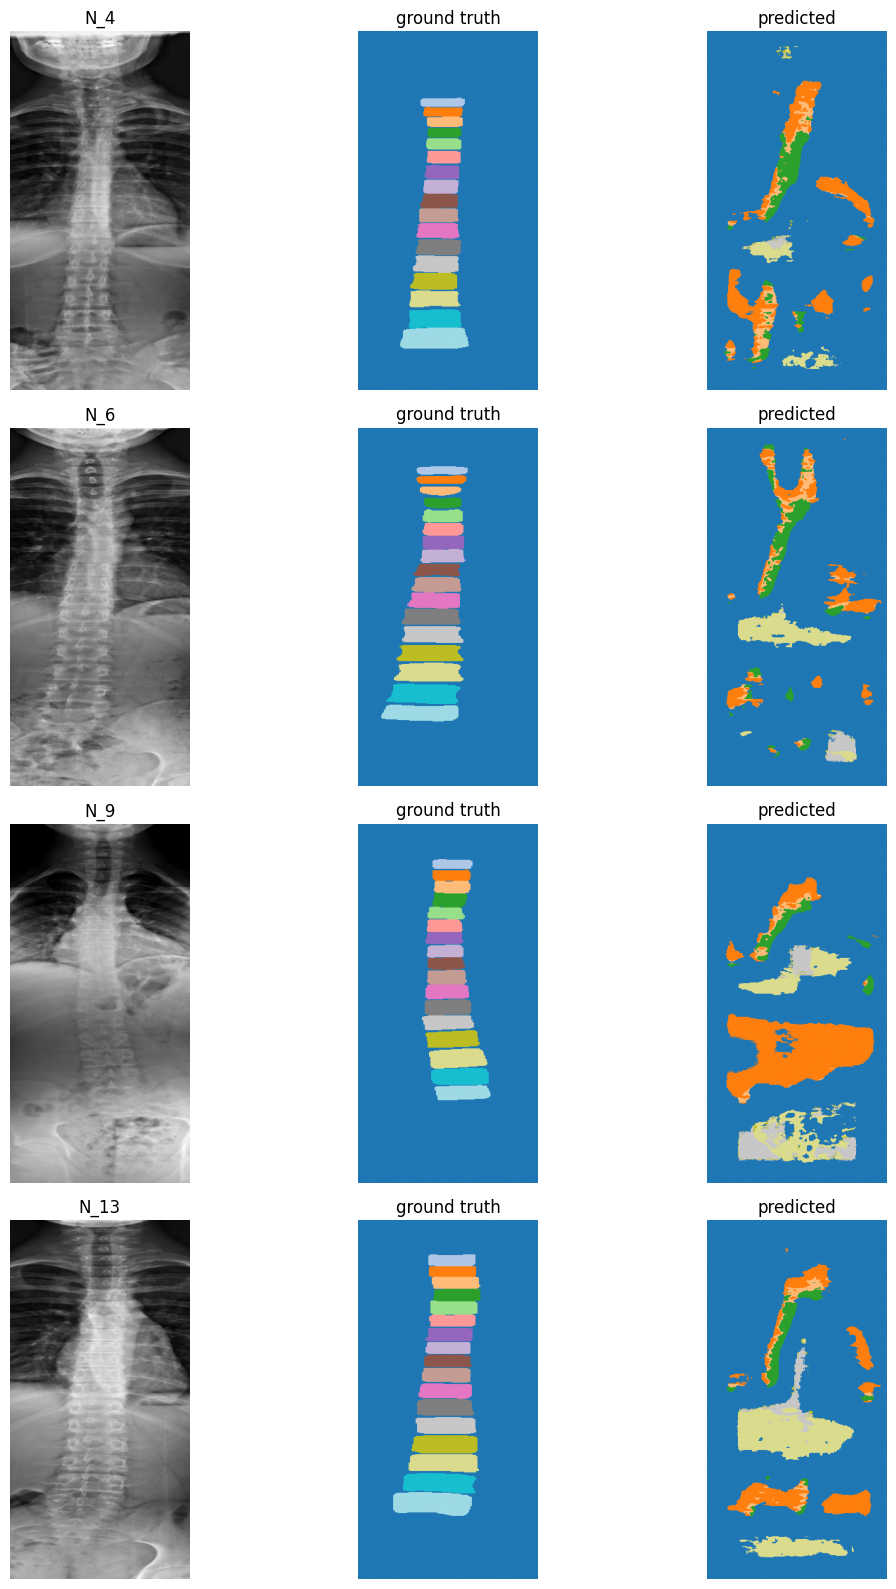

In [23]:
seg_model = Segmenter(init_ch=64).to(DEVICE)
seg_baseline = train(
    seg_model, train_loader, val_loader,
    loss_fn=seg_loss, eval_fn=seg_eval,
    name="seg-baseline", task="segmentation",
    architecture="segmenter", hparams={"init_ch": 64},
    epochs=5, lr=LEARNING_RATE,
)
plot_history(seg_baseline)
plot_seg_predictions(seg_model, VAL_DF, n=4)

  ep01/5  tr=1.4557  va=1.4579  dice=0.003  cobb_mae=38.210  sev_acc=0.600  lr=1.0e-03  (19.4s)
  ep02/5  tr=1.3609  va=1.3628  dice=0.000  cobb_mae=60.108  sev_acc=0.000  lr=1.0e-03  (16.9s)
  ep03/5  tr=1.3395  va=1.3107  dice=0.001  cobb_mae=60.108  sev_acc=0.000  lr=1.0e-03  (19.1s)
  ep04/5  tr=1.3363  va=1.3158  dice=0.000  cobb_mae=60.108  sev_acc=0.000  lr=1.0e-03  (17.0s)
  ep05/5  tr=1.3237  va=1.3987  dice=0.000  cobb_mae=60.108  sev_acc=0.000  lr=1.0e-03  (18.6s)
  restored best (dice=0.003)


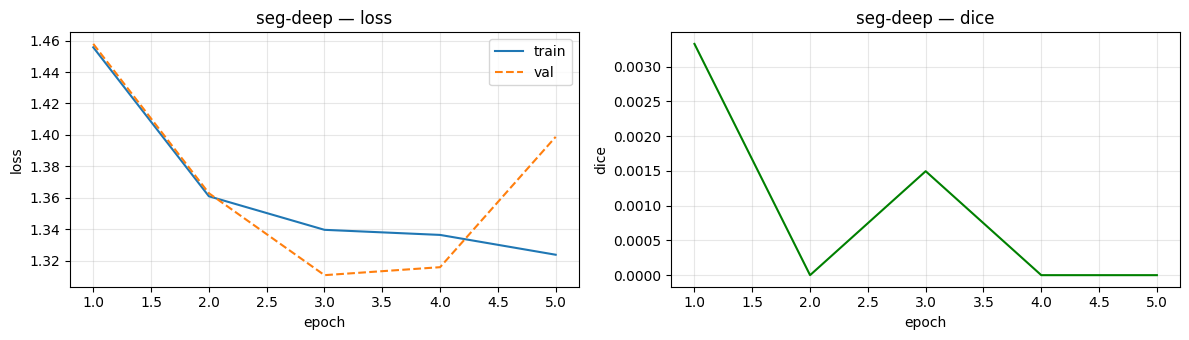

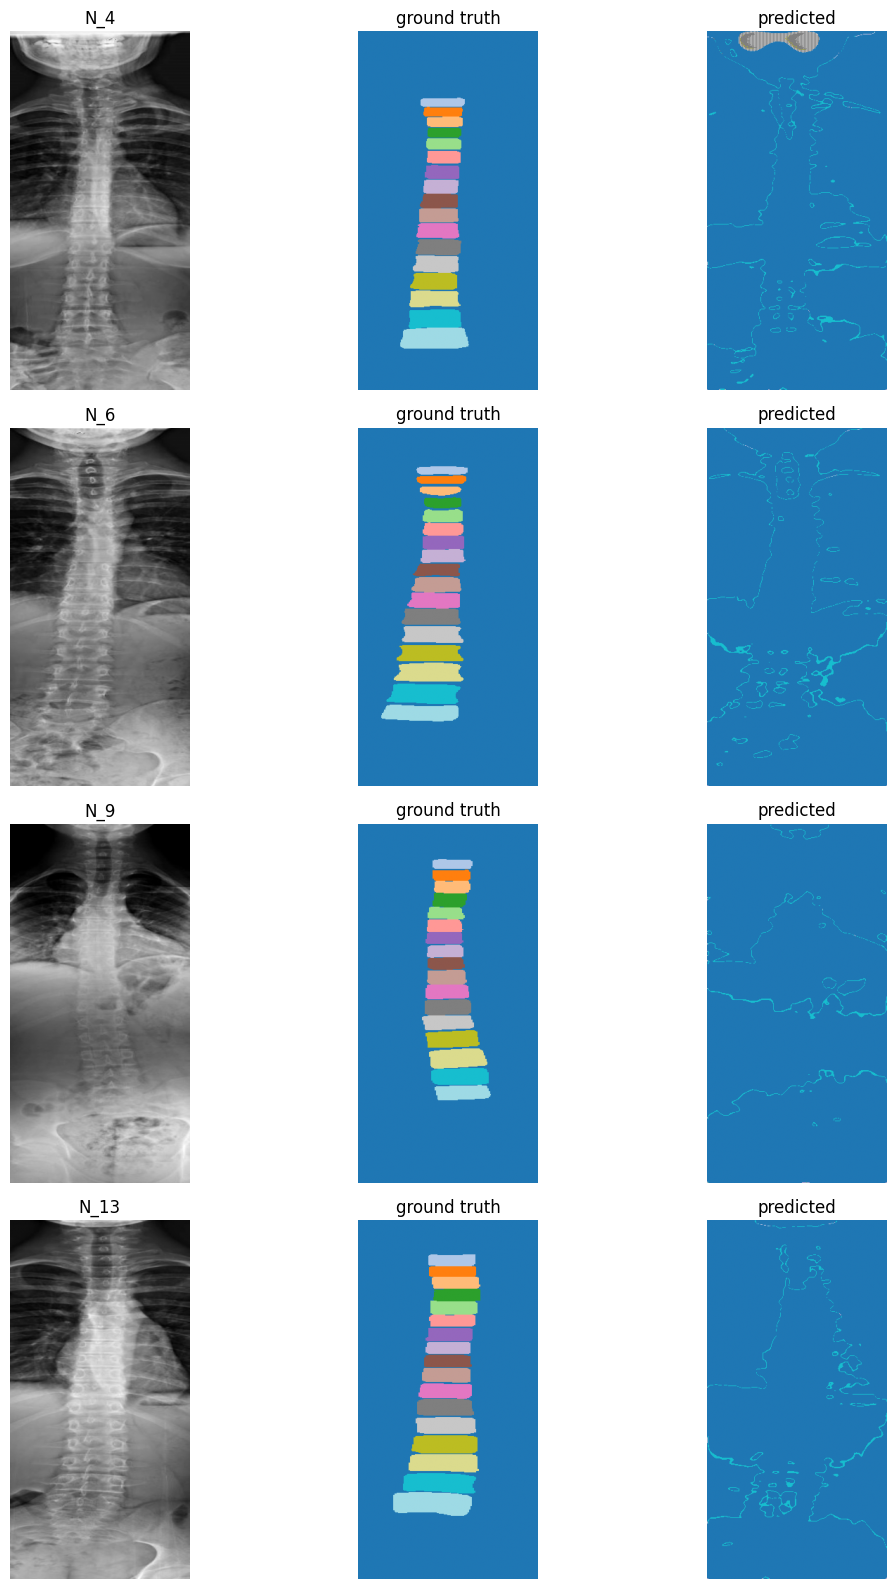

In [24]:
seg_deep_model = SegmenterDeep(init_ch=64).to(DEVICE)
seg_deep = train(
    seg_deep_model, train_loader, val_loader,
    loss_fn=seg_loss, eval_fn=seg_eval,
    name="seg-deep", task="segmentation",
    architecture="segmenter_deep", hparams={"init_ch": 64},
    epochs=5, lr=LEARNING_RATE,
)
plot_history(seg_deep)
plot_seg_predictions(seg_deep_model, VAL_DF, n=4)

  ep01/50  tr=1.4363  va=1.4145  dice=0.000  cobb_mae=56.173  sev_acc=0.200  lr=1.0e-03  (16.1s)
  ep02/50  tr=1.3454  va=1.3128  dice=0.000  cobb_mae=60.108  sev_acc=0.000  lr=1.0e-03  (18.0s)
  ep03/50  tr=1.3090  va=1.2741  dice=0.010  cobb_mae=62.454  sev_acc=0.050  lr=1.0e-03  (16.2s)
  ep04/50  tr=1.2698  va=1.3483  dice=0.024  cobb_mae=28.778  sev_acc=0.750  lr=1.0e-03  (17.5s)
  ep05/50  tr=1.2407  va=1.2310  dice=0.035  cobb_mae=32.690  sev_acc=0.700  lr=1.0e-03  (16.1s)
  ep06/50  tr=1.2071  va=1.1627  dice=0.055  cobb_mae=25.499  sev_acc=0.750  lr=1.0e-03  (17.9s)
  ep07/50  tr=1.2007  va=1.1635  dice=0.065  cobb_mae=25.748  sev_acc=0.750  lr=1.0e-03  (16.0s)
  ep08/50  tr=1.1907  va=1.1713  dice=0.072  cobb_mae=26.265  sev_acc=0.750  lr=1.0e-03  (18.0s)
  ep09/50  tr=1.1724  va=1.1643  dice=0.088  cobb_mae=25.635  sev_acc=0.750  lr=1.0e-03  (16.1s)
  ep10/50  tr=1.1543  va=1.1845  dice=0.078  cobb_mae=16.523  sev_acc=0.800  lr=1.0e-03  (17.9s)
  ep11/50  tr=1.1343  va=1.130

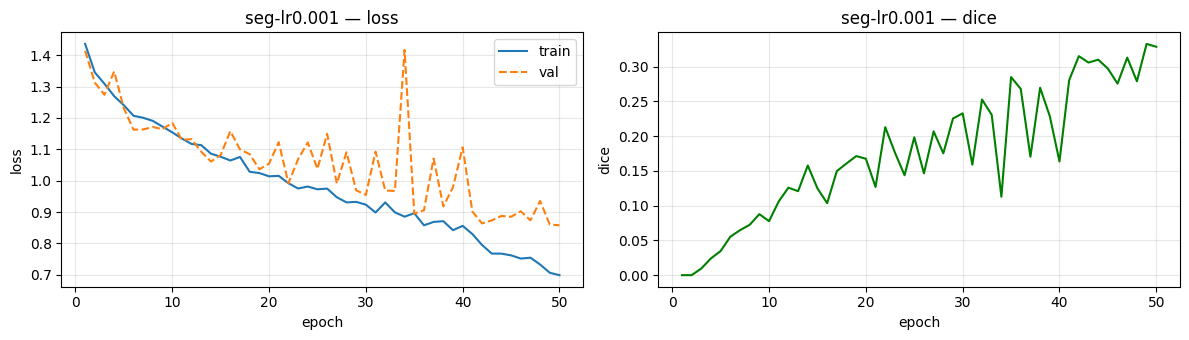

  ep01/50  tr=1.4879  va=1.4494  dice=0.002  cobb_mae=28.697  sev_acc=0.750  lr=5.0e-04  (20.9s)
  ep02/50  tr=1.4094  va=1.3834  dice=0.002  cobb_mae=55.626  sev_acc=0.250  lr=5.0e-04  (19.3s)
  ep03/50  tr=1.3675  va=1.3655  dice=0.005  cobb_mae=46.078  sev_acc=0.300  lr=5.0e-04  (21.1s)
  ep04/50  tr=1.3342  va=1.3146  dice=0.012  cobb_mae=26.139  sev_acc=0.700  lr=5.0e-04  (20.9s)
  ep05/50  tr=1.3053  va=1.2788  dice=0.025  cobb_mae=29.636  sev_acc=0.750  lr=5.0e-04  (19.2s)
  ep06/50  tr=1.2681  va=1.2400  dice=0.043  cobb_mae=20.514  sev_acc=0.750  lr=5.0e-04  (19.0s)
  ep07/50  tr=1.2292  va=1.2507  dice=0.055  cobb_mae=24.593  sev_acc=0.700  lr=5.0e-04  (19.1s)
  ep08/50  tr=1.2201  va=1.2315  dice=0.040  cobb_mae=23.855  sev_acc=0.750  lr=5.0e-04  (22.7s)
  ep09/50  tr=1.1857  va=1.1673  dice=0.080  cobb_mae=21.182  sev_acc=0.700  lr=5.0e-04  (18.8s)
  ep10/50  tr=1.1642  va=1.1842  dice=0.081  cobb_mae=18.932  sev_acc=0.750  lr=5.0e-04  (20.5s)
  ep11/50  tr=1.1352  va=1.140

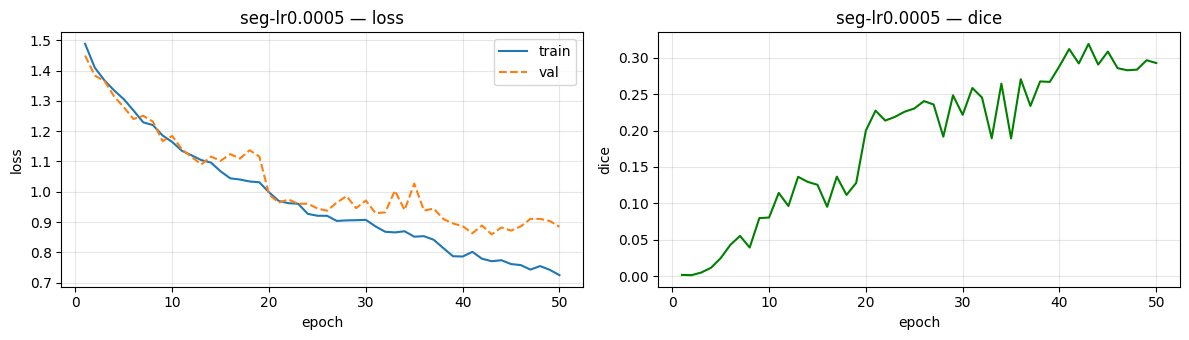

  ep01/50  tr=1.5282  va=1.5551  dice=0.013  cobb_mae=24.386  sev_acc=0.750  lr=1.0e-04  (18.6s)
  ep02/50  tr=1.4684  va=1.4563  dice=0.010  cobb_mae=32.179  sev_acc=0.700  lr=1.0e-04  (20.8s)
  ep03/50  tr=1.4524  va=1.4891  dice=0.013  cobb_mae=30.294  sev_acc=0.750  lr=1.0e-04  (19.2s)
  ep04/50  tr=1.4397  va=1.4278  dice=0.012  cobb_mae=29.203  sev_acc=0.700  lr=1.0e-04  (21.0s)
  ep05/50  tr=1.4232  va=1.4182  dice=0.013  cobb_mae=26.983  sev_acc=0.750  lr=1.0e-04  (20.6s)
  ep06/50  tr=1.4162  va=1.4067  dice=0.014  cobb_mae=28.669  sev_acc=0.700  lr=1.0e-04  (19.0s)
  ep07/50  tr=1.3968  va=1.3861  dice=0.014  cobb_mae=26.310  sev_acc=0.750  lr=1.0e-04  (20.4s)
  ep08/50  tr=1.3794  va=1.3771  dice=0.024  cobb_mae=28.317  sev_acc=0.700  lr=1.0e-04  (18.4s)
  ep09/50  tr=1.3609  va=1.3379  dice=0.030  cobb_mae=29.085  sev_acc=0.750  lr=1.0e-04  (20.9s)
  ep10/50  tr=1.3429  va=1.3296  dice=0.052  cobb_mae=27.782  sev_acc=0.750  lr=1.0e-04  (18.7s)
  ep11/50  tr=1.3162  va=1.289

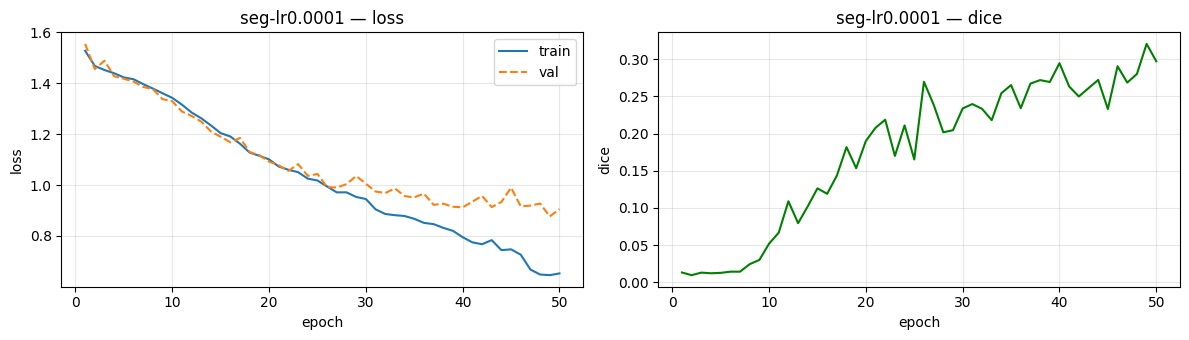

In [25]:
SEG_SWEEP = [
    {"lr": 1e-3, "epochs": 50},
    {"lr": 5e-4, "epochs": 50},
    {"lr": 1e-4, "epochs": 50},
]

for cfg in SEG_SWEEP:
    m = Segmenter(init_ch=64).to(DEVICE)
    r = train(
        m, train_loader, val_loader,
        loss_fn=seg_loss, eval_fn=seg_eval,
        name=f"seg-lr{cfg['lr']}", task="segmentation",
        architecture="segmenter", hparams={"init_ch": 64, **cfg},
        epochs=cfg["epochs"], lr=cfg["lr"],
    )
    plot_history(r)

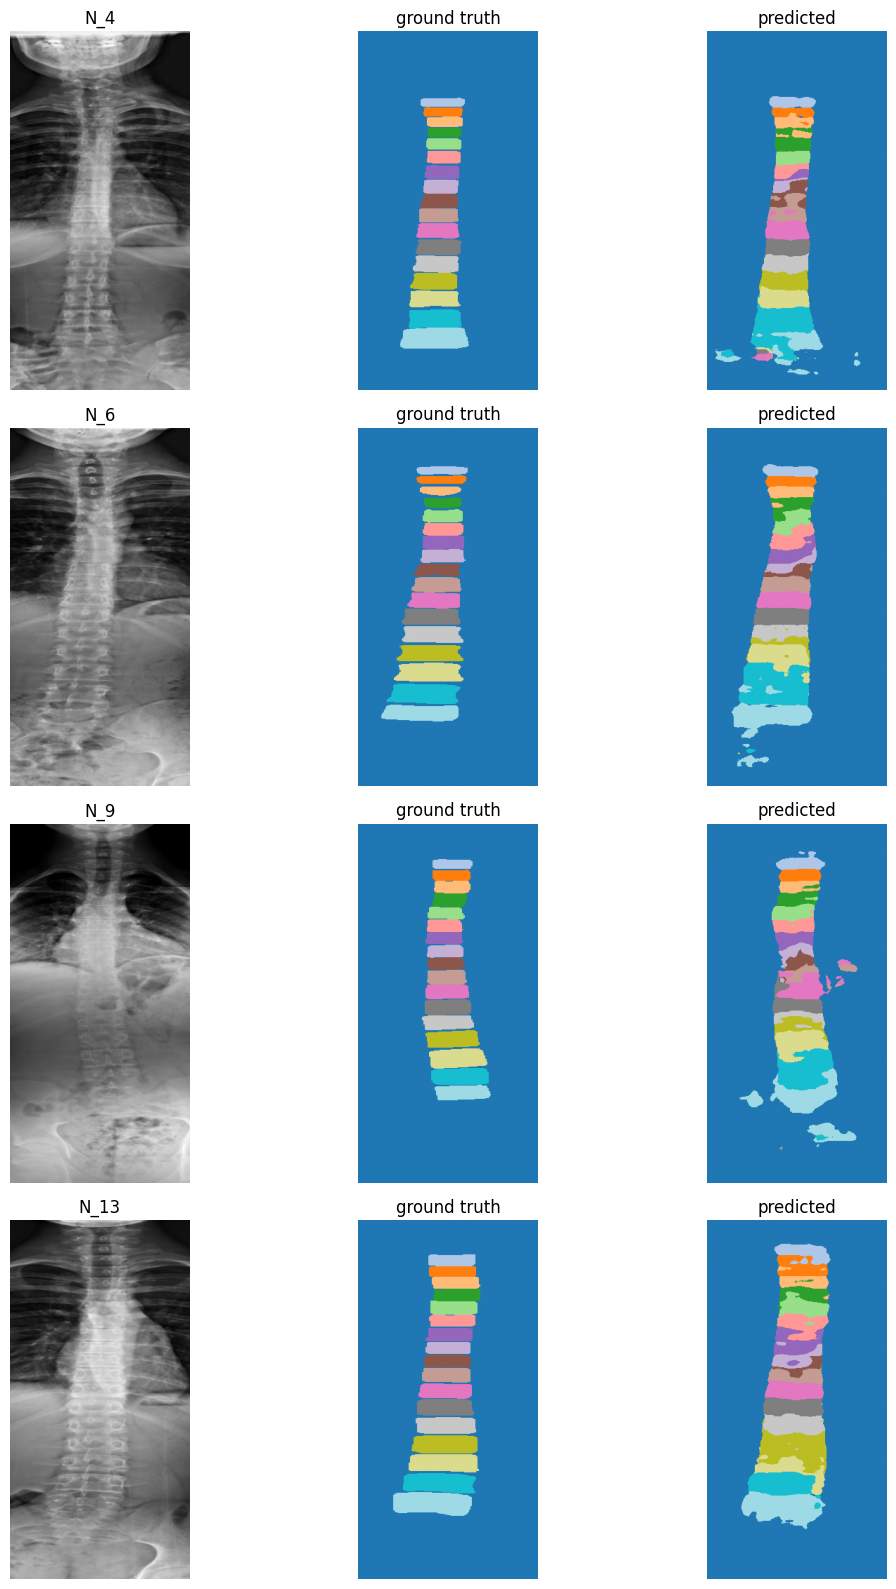

In [26]:
plot_seg_predictions(m, VAL_DF, n=4)

## 10 · Run comparison

In [27]:
def build_run_table() -> pd.DataFrame:
    if not RUN_LOG:
        print("No runs yet.")
        return pd.DataFrame()

    rows = []
    for r in RUN_LOG:
        m = r.best_metrics
        rows.append({
            "name": r.name,
            "task": r.task,
            "arch": r.architecture,
            "lr": r.hparams.get("lr", r.hparams.get("learning_rate", "")),
            "epochs": len(r.history),
            "val_loss": m.get("val_loss", float("nan")),
            "pck": m.get("pck", float("nan")),
            "dice": m.get("dice", float("nan")),
            "cobb_mae": m.get("cobb_mae", float("nan")),
            "sev_acc": m.get("sev_acc", float("nan")),
            "wall_s": r.wall_clock_s,
        })
    df = pd.DataFrame(rows)
    df = df.sort_values(["cobb_mae", "sev_acc"],
                        ascending=[True, False]).reset_index(drop=True)
    return df


run_df = build_run_table()
run_df

,name,task,arch,lr,epochs,val_loss,pck,dice,cobb_mae,sev_acc,wall_s
0,seg-lr0.001,segmentation,segmenter,0.001,50,0.860252,NaN,0.332509,17.305731,0.85,937.344855
1,seg-lr0.0001,segmentation,segmenter,0.0001,50,0.876767,NaN,0.320579,17.910521,0.75,996.471625
2,seg-lr0.0005,segmentation,segmenter,0.0005,50,0.859524,NaN,0.318845,22.246885,0.70,975.058662
3,kp-heatmap-baseline,keypoint,heatmap,,5,93.572020,0.011564,NaN,28.299940,0.75,83.374061
4,seg-baseline,segmentation,segmenter,,5,1.285635,NaN,0.016658,31.028006,0.75,86.774051
5,seg-deep,segmentation,segmenter_deep,,5,1.457897,NaN,0.003326,38.209869,0.60,91.052808
6,kp-regressor-baseline,keypoint,regressor,,5,24.490835,0.387315,NaN,43.793094,0.00,69.528224
7,kp-reg-lr0.0001,keypoint,regressor,0.0001,50,23.593367,0.413841,NaN,52.857364,0.00,669.780818
8,kp-reg-lr0.0005,keypoint,regressor,0.0005,50,23.069993,0.431750,NaN,56.098483,0.00,674.766863
9,kp-reg-lr0.001,keypoint,regressor,0.001,50,23.158437,0.431295,NaN,58.349767,0.00,675.681916


In [28]:
if not run_df.empty:
    best = run_df.iloc[0]
    print(f"Best run: {best['name']}")
    print(f"  cobb_mae = {best['cobb_mae']:.2f}")
    print(f"  sev_acc  = {best['sev_acc']:.3f}")
    print(f"  wall     = {best['wall_s']:.0f}s")

Best run: seg-lr0.001
  cobb_mae = 17.31
  sev_acc  = 0.850
  wall     = 937s


## 11 · SpineNET — Enhanced architecture

Three enhancements over vanilla U-Net:
1. **Attention gates** on skip connections — focus decoder on vertebra regions
2. **Residual connections** in conv blocks — better gradient flow
3. **Deep supervision** — auxiliary losses at 1/2 and 1/4 resolution

In [ ]:
class AttentionGate(nn.Module):
    """Soft attention on skip connection features using gate signal from decoder."""

    def __init__(self, gate_ch: int, skip_ch: int, inter_ch: int) -> None:
        super().__init__()
        self.w_gate = nn.Conv2d(gate_ch, inter_ch, 1, bias=False)
        self.w_skip = nn.Conv2d(skip_ch, inter_ch, 1, bias=False)
        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, 1, bias=False),
            nn.BatchNorm2d(1),
        )

    def forward(self, gate: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        g = self.w_gate(gate)
        s = self.w_skip(skip)
        alpha = torch.sigmoid(self.psi(F.relu(g + s, inplace=True)))
        return skip * alpha


class ResDoubleConv(nn.Module):
    """Two 3x3 convs with BN + ReLU and a residual shortcut."""

    def __init__(self, in_ch: int, out_ch: int) -> None:
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.shortcut = (
            nn.Conv2d(in_ch, out_ch, 1, bias=False)
            if in_ch != out_ch else nn.Identity()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.relu(self.block(x) + self.shortcut(x))

In [ ]:
class SpineNetBackbone(nn.Module):
    """4-level U-Net with attention gates + residual conv blocks.
    Returns (d1, d2, d3) decoder outputs for deep supervision."""

    def __init__(self, in_ch: int = 1, init_ch: int = 64) -> None:
        super().__init__()
        c1, c2, c3, c4 = init_ch, init_ch * 2, init_ch * 4, init_ch * 8

        # Encoder
        self.enc1 = ResDoubleConv(in_ch, c1)
        self.enc2 = ResDoubleConv(c1, c2)
        self.enc3 = ResDoubleConv(c2, c3)
        self.enc4 = ResDoubleConv(c3, c4)
        self.pool = nn.MaxPool2d(2)

        # Decoder level 3 (1/4 res)
        self.up3 = nn.ConvTranspose2d(c4, c3, 2, stride=2)
        self.ag3 = AttentionGate(c3, c3, c3 // 2)
        self.dec3 = ResDoubleConv(c3 + c3, c3)

        # Decoder level 2 (1/2 res)
        self.up2 = nn.ConvTranspose2d(c3, c2, 2, stride=2)
        self.ag2 = AttentionGate(c2, c2, c2 // 2)
        self.dec2 = ResDoubleConv(c2 + c2, c2)

        # Decoder level 1 (full res)
        self.up1 = nn.ConvTranspose2d(c2, c1, 2, stride=2)
        self.ag1 = AttentionGate(c1, c1, c1 // 2)
        self.dec1 = ResDoubleConv(c1 + c1, c1)

        self.out_channels = c1

    def forward(self, x: torch.Tensor):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        u3 = self.up3(e4)
        d3 = self.dec3(torch.cat([u3, self.ag3(u3, e3)], dim=1))

        u2 = self.up2(d3)
        d2 = self.dec2(torch.cat([u2, self.ag2(u2, e2)], dim=1))

        u1 = self.up1(d2)
        d1 = self.dec1(torch.cat([u1, self.ag1(u1, e1)], dim=1))

        return d1, d2, d3


class SpineNetSeg(nn.Module):
    """SpineNet backbone + segmentation heads with deep supervision."""

    def __init__(self, init_ch: int = 64) -> None:
        super().__init__()
        c1, c2, c3 = init_ch, init_ch * 2, init_ch * 4
        self.backbone = SpineNetBackbone(in_ch=1, init_ch=init_ch)
        self.head1 = nn.Conv2d(c1, NUM_SEG_CLASSES, 1)   # full res
        self.head2 = nn.Conv2d(c2, NUM_SEG_CLASSES, 1)   # 1/2 res
        self.head3 = nn.Conv2d(c3, NUM_SEG_CLASSES, 1)   # 1/4 res

    def forward(self, x: torch.Tensor):
        d1, d2, d3 = self.backbone(x)
        out1 = self.head1(d1)
        if self.training:
            return out1, self.head2(d2), self.head3(d3)
        return out1

In [ ]:
for name, cls in [
    ("Segmenter (vanilla)", Segmenter),
    ("SegmenterDeep (vanilla)", SegmenterDeep),
    ("SpineNetSeg (enhanced)", SpineNetSeg),
]:
    m = cls(init_ch=64)
    print(f"  {name:30s}  {param_count(m)/1e6:.2f}M")
    del m

## 12 · Enhanced training utilities

- **Elastic deformation** — spatially warp images + masks to augment small dataset
- **Deep supervision loss** — auxiliary losses at lower decoder resolutions

In [ ]:
def _gaussian_kernel_2d(sigma: float) -> torch.Tensor:
    """Create a 2D Gaussian kernel for smoothing displacement fields."""
    k = int(6 * sigma + 1) | 1  # kernel size (always odd)
    ax = torch.arange(-k // 2 + 1, k // 2 + 1, dtype=torch.float32)
    g1d = torch.exp(-0.5 * (ax / sigma) ** 2)
    g1d /= g1d.sum()
    return (g1d[:, None] @ g1d[None, :]).unsqueeze(0).unsqueeze(0)


def elastic_deform(
    image_t: torch.Tensor,
    seg_t: torch.Tensor,
    *,
    alpha: float = 80.0,
    sigma: float = 10.0,
    rng: np.random.Generator | None = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Elastic deformation on image (C,H,W) and seg mask (H,W). Pure PyTorch."""
    if rng is None:
        rng = np.random.default_rng()
    _, H, W = image_t.shape

    # Random displacement fields
    dx = torch.from_numpy(rng.standard_normal((1, 1, H, W)).astype(np.float32))
    dy = torch.from_numpy(rng.standard_normal((1, 1, H, W)).astype(np.float32))

    # Smooth with Gaussian
    kernel = _gaussian_kernel_2d(sigma)
    pad = kernel.shape[-1] // 2
    dx = F.conv2d(F.pad(dx, [pad] * 4, mode="reflect"), kernel).squeeze() * alpha
    dy = F.conv2d(F.pad(dy, [pad] * 4, mode="reflect"), kernel).squeeze() * alpha

    # Build sampling grid: pixel coords + displacement, normalized to [-1, 1]
    gy, gx = torch.meshgrid(
        torch.arange(H, dtype=torch.float32),
        torch.arange(W, dtype=torch.float32),
        indexing="ij",
    )
    grid = torch.stack([
        (gx + dx) / (W - 1) * 2 - 1,
        (gy + dy) / (H - 1) * 2 - 1,
    ], dim=-1).unsqueeze(0)

    # Warp image (bilinear) and seg mask (nearest)
    img_out = F.grid_sample(
        image_t.unsqueeze(0), grid, mode="bilinear",
        padding_mode="border", align_corners=True,
    ).squeeze(0)
    seg_out = F.grid_sample(
        seg_t.float().unsqueeze(0).unsqueeze(0), grid, mode="nearest",
        padding_mode="border", align_corners=True,
    ).squeeze(0).squeeze(0).long()

    return img_out, seg_out


# Quick visual sanity check
_ds = SpineDataset(TRAIN_DF.head(1), augment=False)
_img, _tgt, _ = _ds[0]
_img_d, _seg_d = elastic_deform(_img, _tgt["seg_mask"], alpha=80, sigma=10)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(_img.squeeze(0), cmap="gray"); axes[0].set_title("original")
axes[1].imshow(_tgt["seg_mask"], cmap="tab20"); axes[1].set_title("GT seg")
axes[2].imshow(_img_d.squeeze(0), cmap="gray"); axes[2].set_title("deformed")
axes[3].imshow(_seg_d, cmap="tab20"); axes[3].set_title("deformed seg")
for ax in axes: ax.set_axis_off()
plt.tight_layout(); plt.show()
del _ds, _img, _tgt, _img_d, _seg_d

In [ ]:
class EnhancedSpineDataset(SpineDataset):
    """SpineDataset + elastic deformation for segmentation training."""

    def __init__(
        self, *args,
        elastic_alpha: float = 80.0,
        elastic_sigma: float = 10.0,
        elastic_prob: float = 0.3,
        **kwargs,
    ) -> None:
        super().__init__(*args, **kwargs)
        self.elastic_alpha = elastic_alpha
        self.elastic_sigma = elastic_sigma
        self.elastic_prob = elastic_prob

    def __getitem__(self, idx: int):
        image_t, targets, meta = super().__getitem__(idx)
        if self.augment and self._rng.random() < self.elastic_prob:
            image_t, targets["seg_mask"] = elastic_deform(
                image_t, targets["seg_mask"],
                alpha=self.elastic_alpha, sigma=self.elastic_sigma,
                rng=self._rng,
            )
        return image_t, targets, meta


def make_enhanced_loaders(
    train_df: pd.DataFrame, val_df: pd.DataFrame, *,
    batch_size: int = BATCH_SIZE, seed: int = SEED,
    elastic: bool = True,
) -> tuple[DataLoader, DataLoader]:
    if elastic:
        train_ds = EnhancedSpineDataset(train_df, augment=True, seed=seed)
    else:
        train_ds = SpineDataset(train_df, augment=True, seed=seed)
    val_ds = SpineDataset(val_df, augment=False)
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0),
    )

print("EnhancedSpineDataset ready")

In [ ]:
def spinenet_seg_loss(model: nn.Module, batch) -> torch.Tensor:
    """Seg loss with deep supervision: 1.0*full + 0.3*half + 0.1*quarter."""
    imgs, tgts, _ = batch
    target = tgts["seg_mask"].to(DEVICE).long()
    outputs = model(imgs.to(DEVICE))

    if isinstance(outputs, tuple):
        out1, out2, out3 = outputs
        loss1 = seg_combo_loss(out1, target)
        t2 = F.interpolate(
            target.unsqueeze(1).float(), scale_factor=0.5, mode="nearest",
        ).squeeze(1).long()
        t3 = F.interpolate(
            target.unsqueeze(1).float(), scale_factor=0.25, mode="nearest",
        ).squeeze(1).long()
        return loss1 + 0.3 * seg_combo_loss(out2, t2) + 0.1 * seg_combo_loss(out3, t3)

    return seg_combo_loss(outputs, target)


# seg_eval works unchanged for SpineNetSeg:
# - During eval, model returns single tensor (self.training is False)
# - seg_eval calls model(imgs) -> gets (B, C, H, W) logits -> argmax -> Dice + Cobb
# No wrapper needed.

print("spinenet_seg_loss ready (seg_eval reused as-is)")

## 13 · SpineNET experiments

Ablation study:
1. SpineNet (attention + residual) with standard loss
2. SpineNet + deep supervision
3. SpineNet + deep supervision + elastic augmentation
4. SpineNet + deep sup + elastic + cosine annealing (full enhancement)

In [ ]:
std_loader_tr, std_loader_va = make_loaders(TRAIN_DF, VAL_DF)

# Ablation 1: attention + residual only (no deep sup, standard aug)
sn_model_1 = SpineNetSeg(init_ch=64).to(DEVICE)
sn_baseline = train(
    sn_model_1, std_loader_tr, std_loader_va,
    loss_fn=seg_loss, eval_fn=seg_eval,
    name="spinenet-attn-res", task="segmentation",
    architecture="spinenet_seg", hparams={"init_ch": 64, "deep_sup": False},
    epochs=50, lr=1e-3,
)
plot_history(sn_baseline)
plot_seg_predictions(sn_model_1, VAL_DF, n=4)

In [ ]:
# Ablation 2: attention + residual + deep supervision
sn_model_2 = SpineNetSeg(init_ch=64).to(DEVICE)
sn_deepsup = train(
    sn_model_2, std_loader_tr, std_loader_va,
    loss_fn=spinenet_seg_loss, eval_fn=seg_eval,
    name="spinenet-deepsup", task="segmentation",
    architecture="spinenet_seg", hparams={"init_ch": 64, "deep_sup": True},
    epochs=50, lr=1e-3,
)
plot_history(sn_deepsup)
plot_seg_predictions(sn_model_2, VAL_DF, n=4)

In [ ]:
enh_loader_tr, enh_loader_va = make_enhanced_loaders(TRAIN_DF, VAL_DF, elastic=True)

# Ablation 3: deep sup + elastic augmentation
sn_model_3 = SpineNetSeg(init_ch=64).to(DEVICE)
sn_elastic = train(
    sn_model_3, enh_loader_tr, enh_loader_va,
    loss_fn=spinenet_seg_loss, eval_fn=seg_eval,
    name="spinenet-deepsup-elastic", task="segmentation",
    architecture="spinenet_seg",
    hparams={"init_ch": 64, "deep_sup": True, "elastic": True},
    epochs=50, lr=1e-3,
)
plot_history(sn_elastic)
plot_seg_predictions(sn_model_3, VAL_DF, n=4)

In [ ]:
# Full enhancement: deep sup + elastic + cosine annealing — LR sweep
SPINENET_SWEEP = [
    {"lr": 1e-3, "epochs": 50},
    {"lr": 5e-4, "epochs": 50},
]

for cfg in SPINENET_SWEEP:
    m = SpineNetSeg(init_ch=64).to(DEVICE)
    r = train(
        m, enh_loader_tr, enh_loader_va,
        loss_fn=spinenet_seg_loss, eval_fn=seg_eval,
        name=f"spinenet-full-lr{cfg['lr']}", task="segmentation",
        architecture="spinenet_seg",
        hparams={"init_ch": 64, "deep_sup": True, "elastic": True,
                 "cosine": True, **cfg},
        epochs=cfg["epochs"], lr=cfg["lr"], cosine=True,
    )
    plot_history(r)

In [ ]:
plot_seg_predictions(m, VAL_DF, n=4)

## 14 · Full comparison — vanilla U-Net vs SpineNET

In [ ]:
full_df = build_run_table()
full_df

In [ ]:
if not full_df.empty:
    # Best segmentation run
    seg_runs = full_df[full_df["task"] == "segmentation"].copy()
    if not seg_runs.empty:
        best = seg_runs.iloc[0]
        print(f"Best segmentation run: {best['name']}")
        print(f"  dice     = {best['dice']:.3f}")
        print(f"  cobb_mae = {best['cobb_mae']:.2f}")
        print(f"  sev_acc  = {best['sev_acc']:.3f}")
        print(f"  wall     = {best['wall_s']:.0f}s")
        print()

    # Vanilla vs SpineNET comparison
    vanilla_best = seg_runs[~seg_runs["name"].str.startswith("spinenet")]
    spinenet_best = seg_runs[seg_runs["name"].str.startswith("spinenet")]
    if not vanilla_best.empty and not spinenet_best.empty:
        v = vanilla_best.iloc[0]
        s = spinenet_best.iloc[0]
        print("Vanilla vs SpineNET:")
        print(f"  {'metric':12s} {'vanilla':>10s} {'spinenet':>10s} {'delta':>10s}")
        for col in ["dice", "cobb_mae", "sev_acc"]:
            vv, sv = v[col], s[col]
            d = sv - vv
            print(f"  {col:12s} {vv:10.3f} {sv:10.3f} {d:+10.3f}")